In [3]:
from conllu import parse

In [4]:
with open ('../benchmark/tokenize/vi_vtb-ud-test.conllu', 'r', encoding='utf-8') as f:
	text = f.read()
	
sentences = parse(text)

In [5]:
text = ''
sents = []
groundtruth = []
for tokenlist in sentences:
	tagged = []
	sent = tokenlist.metadata['text']
	for item in tokenlist:
		#print(item['form'],item['xpos'])
		tagged.append([item['form'],item['xpos'],' '])
	text += sent + ' '
	groundtruth.append(tagged)
	sents.append(sent)
	
groundtruth[0]

[['Thanh', 'NNP', ' '],
 ['bắt chuyện', 'V', ' '],
 ['với', 'Pre', ' '],
 ['Hùng', 'NNP', ' '],
 ['và', 'CC', ' '],
 ['nói', 'V', ' '],
 [':', ':', ' '],
 ['"', '``', ' '],
 ['Tôi', 'Pro', ' '],
 ['trông', 'V', ' '],
 ['ông', 'N', ' '],
 ['quen quen', 'V', ' '],
 ['?', '?', ' '],
 ['"', '``', ' '],
 ['.', '.', ' ']]

In [6]:
from pyvi import ViTokenizer, ViPosTagger


class Spacy_tokenize:

    def __init__(self):
        pass

    def tokenize(self, text):
        output = []

        # doc = self.nlp(text)
        # for token in doc:
        #     output.append([token.text, token.tag_, ""])
        #     # print(token.text, token.lemma_, token.tag_, token.pos_, token.dep_,
        #     #       token.shape_, token.is_alpha, token.is_stop)

        
        tokens = ViTokenizer.tokenize(text)
        postag = ViPosTagger.postagging(ViTokenizer.tokenize(text))

        for (token, pos) in zip(postag[0], postag[1]) :
            output.append([token, pos])

        return output

    def info(self):
        return "PyVi"

In [7]:
cla = Spacy_tokenize()

cla.tokenize("Trường đại học bách khoa hà nội")

[['Trường', 'N'], ['đại_học', 'N'], ['bách_khoa', 'Np'], ['hà_nội', 'Np']]

In [8]:
from underthesea import word_tokenize
from underthesea import ner

class Underthesea_tokenize:
    def __init__(self):
        pass

    def tokenize(self, text):
        output = []
        ners = ner(text)
        for item in ners:
            output.append([item[0], item[1], item[3]])

        return output

    def info(self):
        return "Underthesea"

In [9]:
cla = Underthesea_tokenize()

cla.tokenize("Trường đại học bách khoa hà nội")

[['Trường', 'N', 'O'],
 ['đại học', 'N', 'O'],
 ['bách khoa', 'N', 'B-LOC'],
 ['hà nội', 'M', 'I-LOC']]

In [10]:
import py_vncorenlp

class VncoreNLP_tokenize:

    # To perform word segmentation, POS tagging, NER and dependency parsing
    # annotator = VnCoreNLP("VnCoreNLP-1.1.1.jar", annotators="wseg,pos,ner,parse", max_heap_size='-Xmx2g')

    def __init__(self):
        # self.annotator = py_vncorenlp.VnCoreNLP(save_dir='../model')
        # Automatically download VnCoreNLP components from the original repository
        # and save them in some local working folder
        py_vncorenlp.download_model(save_dir='../model')

        # Load VnCoreNLP from the local working folder that contains both `VnCoreNLP-1.2.jar` and `models` 
        self.model = py_vncorenlp.VnCoreNLP(save_dir='../model')


    def tokenize(self, text):
        output = []
        annotated_text = self.model.annotate_text(text)[0]

        for sent in annotated_text:
            output.append([
                sent['wordForm'].replace('_', ' '),
                sent['posTag'],
                sent['nerLabel']
            ])

        return output

    def close(self):
        pass

    def info(self):
        return "VnCoreNLP"

In [11]:
from time import perf_counter

running_result = []

for tokenizer_class in (Spacy_tokenize, Underthesea_tokenize, VncoreNLP_tokenize):
    t = tokenizer_class()

    count = 0
    wordcount = 0
    poscount = 0
    sercount = 0

    total_time = 0
    index = 0

    for sent in sents:
        start = perf_counter()
        predict = t.tokenize(sent)
        total_time += perf_counter() - start

        count += len(groundtruth[index])

        # Compare prediction with ground truth
        if len(predict) == len(groundtruth[index]):
            for item, gt in zip(predict, groundtruth[index]):  # item = [word, pos, entity]

                if item[0] == gt[0]:
                    wordcount += 1
                if item[1] == gt[1]:
                    poscount += 1

        index += 1

    # Accuracy calculations
    wordsegacc = wordcount / count
    posacc = poscount / count

    print()
    print(t.info())
    print(
        "Tagging time:", total_time,
        "Accuracy: Word segmentation", wordsegacc,
        "Pos tag", posacc
    )

    running_result.append({
        'class_name': t.__class__.__name__,
        'Total time': total_time,
        'Accuracy: Word segmentation': wordsegacc
    })

    # Close annotator if tokenizer has close()
    if hasattr(t, "close"):
        t.close()

    # break


PyVi
Tagging time: 0.2678166479977335 Accuracy: Word segmentation 0.6416353061922682 Pos tag 0.32090318166267534

Underthesea
Tagging time: 3.3332094940042225 Accuracy: Word segmentation 0.6515566199110503 Pos tag 0.2672767704413274
VnCoreNLP model folder ../model already exists! Please load VnCoreNLP from this folder!
2026-03-17 17:48:42 INFO  WordSegmenter:24 - Loading Word Segmentation model
2026-03-17 17:48:42 INFO  PosTagger:23 - Loading POS Tagging model
2026-03-17 17:48:44 INFO  NerRecognizer:34 - Loading NER model
2026-03-17 17:48:50 INFO  DependencyParser:32 - Loading Dependency Parsing model

VnCoreNLP
Tagging time: 1.4748861360035335 Accuracy: Word segmentation 0.8097844680123161 Pos tag 0.35862127950735545


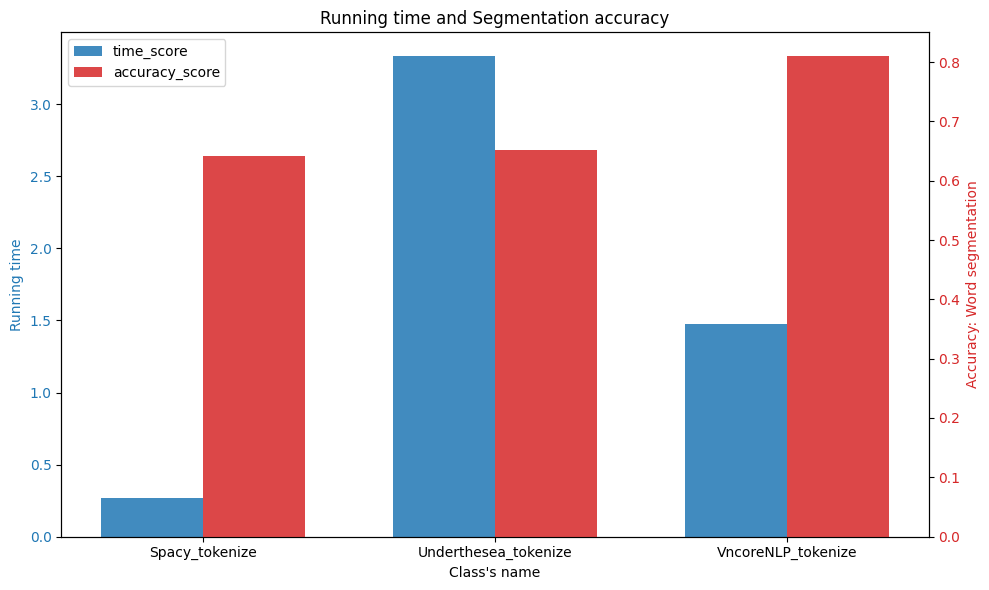

<Figure size 640x480 with 0 Axes>

In [12]:
import matplotlib.pyplot as plt
import numpy as np

names = [item['class_name'] for item in running_result]
total_time = [item['Total time'] for item in running_result]
accuracy = [item['Accuracy: Word segmentation'] for item in running_result]

fig, ax1 = plt.subplots(figsize=(10, 6))

x = np.arange(len(names))
width = 0.35

bars1 = ax1.bar(x - width/2, total_time, width, label='time_score', color='tab:blue', alpha=0.85)
ax1.set_xlabel('Class\'s name')
ax1.set_ylabel('Running time', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_xticks(x)
ax1.set_xticklabels(names)

ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, accuracy, width, label='accuracy_score', color='tab:red', alpha=0.85)
ax2.set_ylabel('Accuracy: Word segmentation', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Running time and Segmentation accuracy')

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

plt.tight_layout()
plt.show()

plt.savefig('time_and_accuracy.svg', 
            format='svg',
            bbox_inches='tight',
            dpi=300)